## Transfer Learning

In [1]:
from tensorflow.keras.applications import ResNet50V2

model = ResNet50V2(weights="imagenet")
model.summary()

Model: "resnet50v2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 114, 114, 64)         0         ['conv1_conv[0][0]']          
                                                                                         

In [2]:
# With clasification layer.
base_model = ResNet50V2(weights="imagenet")

# Without classification layer.
base_model = ResNet50V2(weights="imagenet", include_top=False)

Appending classification layers to the base model's bottleneck layers and setting each base layer's trainable attribute to `False` so that the weights, biases and convolution kernels won't be updated:

```python
# Train.
for layer in base_model.layers:
    layer.trainable = False

model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dense(3, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
model.fit(x, y, validation_split=0.2, epochs=10, batch_size=10)

# Predict.
x = image.load_img(
    "./Wildlife/samples/arctic_fox/arctic_fox_140.jpeg", target_size=(224, 224)
)
x = image.img_to_array(x)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
y_pred = base_model.predict(x)
```

Run all the training images through the base model for feature extraction, and then run the features through a separate network containing your classification layer:

```python
# Train.
features = base_model.predict(x)

model = Sequential()
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(3, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
model.fit(features, y, validation_split=0.2, epochs=10, batch_size=10)

# Predict.
x = image.load_img(
    "./Wildlife/samples/arctic_fox/arctic_fox_140.jpeg", target_size=(224, 224)
)
x = image.img_to_array(x)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
features = base_model.predict(x)
predictions = model.predict(features)
```

## Using Transfer Learning to Identify Artic Wildlife 

In [4]:
import numpy as np
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet50 import decode_predictions, preprocess_input
from tensorflow.keras.preprocessing import image

model = ResNet50V2(weights="imagenet")
x = image.load_img("./Wildlife/samples/walrus/walrus_143.png", target_size=(224, 224))
x = image.img_to_array(x)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x) / 255

y = model.predict(x)
decode_predictions(y)

1/1 [==============================] - 0s 283ms/step


[[('n02454379', 'armadillo', 0.63758284),
  ('n01704323', 'triceratops', 0.1605702),
  ('n02113978', 'Mexican_hairless', 0.07795028),
  ('n02398521', 'hippopotamus', 0.022283815),
  ('n01817953', 'African_grey', 0.016944066)]]

We are unable to predict `walrus`, because the model is not trained on that data.

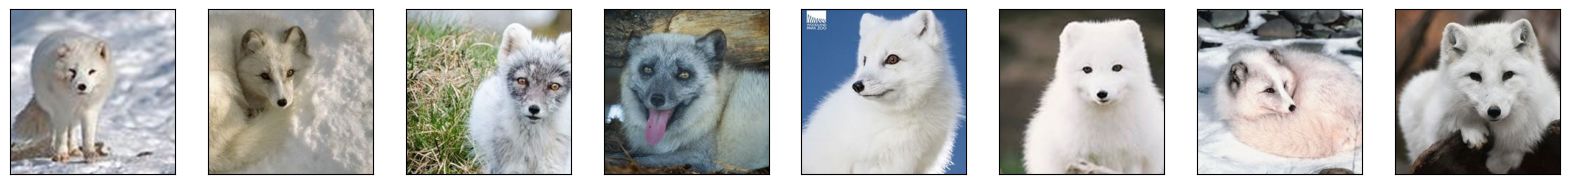

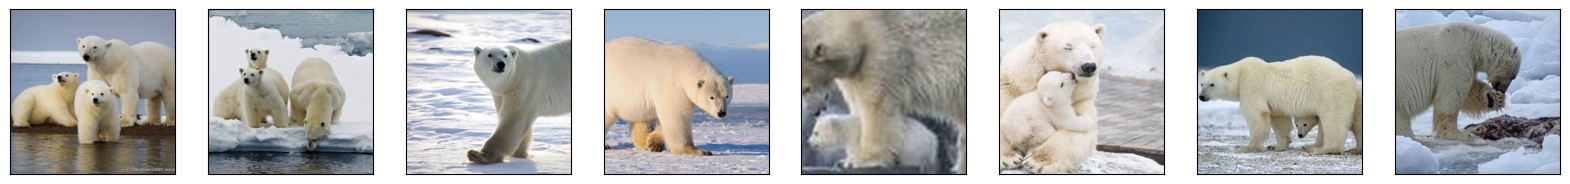

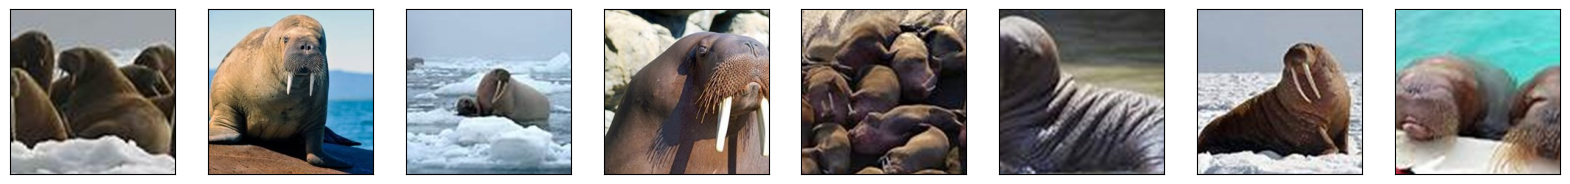

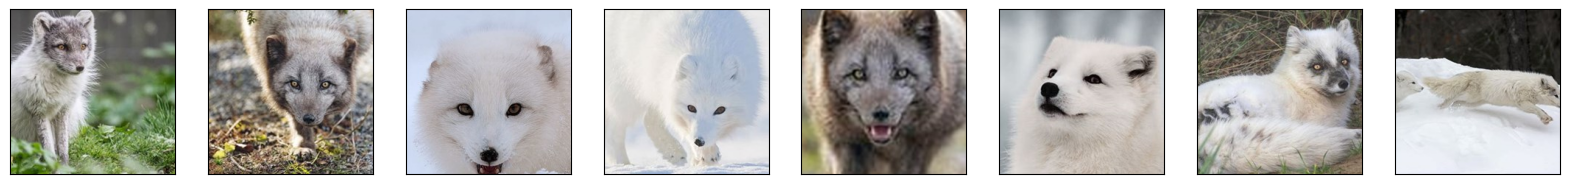

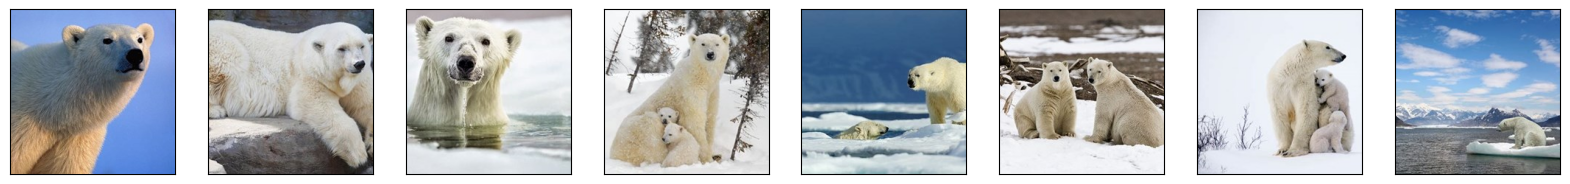

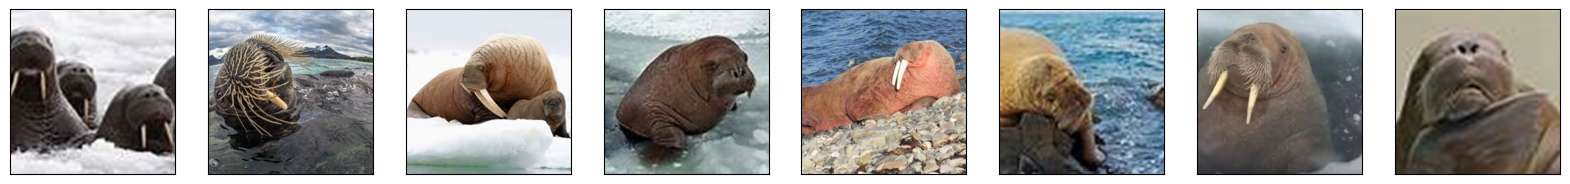

In [8]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image


def load_images_from_path(path, label):
    images, labels = [], []

    for file in os.listdir(path):
        img = image.load_img(Path(path) / file, target_size=(224, 224, 3))
        images.append(image.img_to_array(img))
        labels.append((label))

    return images, labels


def show_images(images):
    fig, axes = plt.subplots(
        1, 8, figsize=(20, 20), subplot_kw={"xticks": [], "yticks": []}
    )

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i] / 255)


X_train, y_train, X_test, y_test = [], [], [], []

for i, animal in enumerate(["arctic_fox", "polar_bear", "walrus"]):
    images, labels = load_images_from_path(Path("Wildlife/train") / animal, i)
    X_train += images
    y_train += labels

    show_images(images)


for i, animal in enumerate(["arctic_fox", "polar_bear", "walrus"]):
    images, labels = load_images_from_path(Path("Wildlife/test") / animal, i)
    X_test += images
    y_test += labels

    show_images(images)

In [9]:
X_train = preprocess_input(np.array(X_train)) / 255
X_test = preprocess_input(np.array(X_test)) / 255

y_train = np.array(y_train)
y_test = np.array(y_test)

In [10]:
base_model = ResNet50V2(weights="imagenet", include_top=False)

X_train = base_model.predict(X_train)
X_test = base_model.predict(X_test)

4/4 [==============================] - 2s 424ms/step


In [11]:
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dense(3, activation="softmax"))
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

hist = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), batch_size=10, epochs=10
)

Epoch 1/10
30/30 [==============================] - 3s 83ms/step - loss: 6.5649 - accuracy: 0.9033 - val_loss: 6.8962 - val_accuracy: 0.9500
Epoch 2/10
30/30 [==============================] - 3s 85ms/step - loss: 1.2793 - accuracy: 0.9833 - val_loss: 11.2166 - val_accuracy: 0.9500
Epoch 3/10
30/30 [==============================] - 2s 83ms/step - loss: 0.8801 - accuracy: 0.9867 - val_loss: 10.1669 - val_accuracy: 0.9417
Epoch 4/10
30/30 [==============================] - 2s 83ms/step - loss: 0.1847 - accuracy: 0.9933 - val_loss: 11.1786 - val_accuracy: 0.9500
Epoch 5/10
30/30 [==============================] - 2s 83ms/step - loss: 0.5548 - accuracy: 0.9900 - val_loss: 22.9178 - val_accuracy: 0.9333
Epoch 6/10
30/30 [==============================] - 2s 83ms/step - loss: 2.3207 - accuracy: 0.9867 - val_loss: 21.1920 - val_accuracy: 0.9167
Epoch 7/10
30/30 [==============================] - 2s 81ms/step - loss: 0.4504 - accuracy: 0.9933 - val_loss: 18.9513 - val_accuracy: 0.9167
Epoch 8

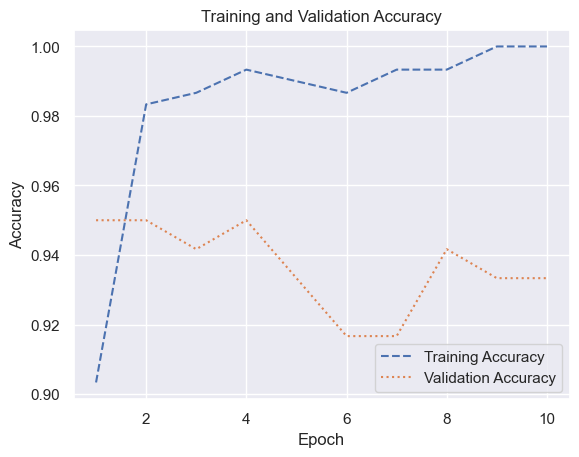

In [12]:
import seaborn as sns

sns.set_theme()

acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "--", label="Training Accuracy")
plt.plot(epochs, val_acc, ":", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right");

4/4 [==============================] - 0s 29ms/step


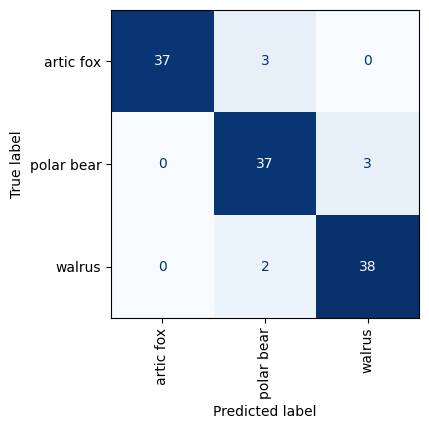

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd

sns.reset_orig()

fig, ax = plt.subplots(figsize=(4, 4))
ax.grid(False)

y_pred = model.predict(X_test)
class_labels = ["artic fox", "polar bear", "walrus"]
cmd.from_predictions(
    y_test,
    y_pred.argmax(axis=1),
    display_labels=class_labels,
    colorbar=False,
    cmap="Blues",
    xticks_rotation="vertical",
    ax=ax,
)
plt.show()

1/1 [==============================] - 0s 21ms/step
artic fox: 1.0
polar bear: 0.0
walrus: 0.0


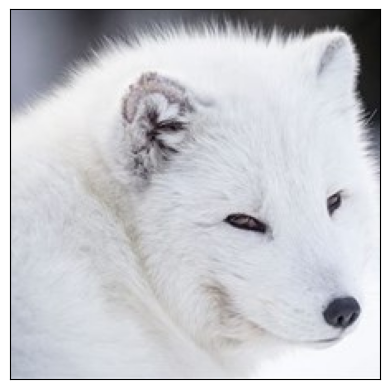

In [14]:
x = image.load_img(
    "./Wildlife/samples/arctic_fox/arctic_fox_140.jpeg", target_size=(224, 224)
)

plt.xticks([])
plt.yticks([])
plt.imshow(x)


x = image.img_to_array(x)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x) / 255

y = base_model.predict(x)
predictions = model.predict(y)

for i, label in enumerate(class_labels):
    print(f"{label}: {predictions[0][i]}")

1/1 [==============================] - 0s 21ms/step
artic fox: 0.0
polar bear: 0.0
walrus: 1.0


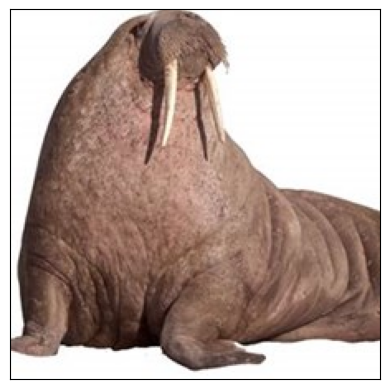

In [15]:
x = image.load_img("./Wildlife/samples/walrus/walrus_143.png", target_size=(224, 224))

plt.xticks([])
plt.yticks([])
plt.imshow(x)


x = image.img_to_array(x)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x) / 255

y = base_model.predict(x)
predictions = model.predict(y)

for i, label in enumerate(class_labels):
    print(f"{label}: {predictions[0][i]}")